# 姿勢分析結果の可視化ノートブック

このノートブックは、`detect_joint_movement_with_hip_stay.py`スクリプトによって生成されたCSVファイルを分析し、結果を可視化するためのものです。

**分析内容:**
1. データの読み込みと基本情報の確認
2. 特定の関節角度の時系列変化のプロット
3. 頭部の動きの軌跡の可視化
4. ランドマークの信頼度(visibility)の分布の確認


In [18]:
import japanize_matplotlib  # 日本語化ライブラリ
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# スタイルの設定
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)

# --- CSVファイルのパスを指定してください ---
# 1. 絶対パスで指定する場合
# csv_path = "/Users/takahashiryoutarou/Desktop/国宝さん一覧/box/output/国宝さん5_integrated_analysis_20250901_083543.csv"

# 2. 相対パスで指定する場合 (このノートブックが `analysis` フォルダにあると仮定)
csv_path = "../output/WIN_20250319_10_03_53_Pro_30sec_integrated_analysis_20250901_102732.csv"


# データの読み込み
try:
    df = pd.read_csv(csv_path)
    print("CSVファイルの読み込みに成功しました。")
    print(f"データフレームの形状: {df.shape}")
except FileNotFoundError:
    print(f"エラー: ファイルが見つかりません。パスを確認してください。 -> {csv_path}")

# データの一部と基本情報を表示
if 'df' in locals():
    display(df.head())
    print("\\n--- データ型の情報 ---")
    df.info()


CSVファイルの読み込みに成功しました。
データフレームの形状: (591, 185)


,timestamp,frame_number,right_elbow_angle,right_elbow_state,left_elbow_angle,left_elbow_state,right_shoulder_angle,right_shoulder_state,left_shoulder_angle,left_shoulder_state,...,RIGHT_HEEL_z,RIGHT_HEEL_visibility,LEFT_FOOT_INDEX_x,LEFT_FOOT_INDEX_y,LEFT_FOOT_INDEX_z,LEFT_FOOT_INDEX_visibility,RIGHT_FOOT_INDEX_x,RIGHT_FOOT_INDEX_y,RIGHT_FOOT_INDEX_z,RIGHT_FOOT_INDEX_visibility
0,0.818797,23,18.426258,STATIC,76.045539,STATIC,84.867268,STATIC,72.253588,STATIC,...,0.055094,0.225219,0.037990,0.765517,-0.025186,0.346129,-0.010539,0.731690,0.022382,0.240400
1,0.854397,24,19.498006,STATIC,85.461878,EXTENSION,82.612361,STATIC,71.226680,STATIC,...,0.060205,0.234997,0.044283,0.766957,-0.031500,0.364914,-0.001681,0.733581,0.020760,0.261786
2,0.889996,25,18.520552,STATIC,84.196709,STATIC,82.048773,STATIC,70.387008,STATIC,...,0.097347,0.240341,0.043778,0.780386,-0.011802,0.373802,0.011539,0.763458,0.050228,0.276411
3,0.925596,26,18.049087,STATIC,77.097548,FLEXION,82.504447,STATIC,71.045924,STATIC,...,0.079484,0.241623,0.051400,0.785847,-0.036650,0.379941,0.029774,0.772873,0.039479,0.285662
4,1.566394,44,15.367607,STATIC,129.113770,EXTENSION,85.452171,STATIC,61.807448,FLEXION,...,0.083479,0.277963,0.088165,0.411327,-0.092165,0.426995,0.096938,0.475131,0.057239,0.319472


\n--- データ型の情報 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 591 entries, 0 to 590
Columns: 185 entries, timestamp to RIGHT_FOOT_INDEX_visibility
dtypes: bool(5), float64(162), int64(1), object(17)
memory usage: 834.1+ KB


## 2. 関節角度の時系列変化

特定の関節の角度が、動画の再生時間を通じてどのように変化したかを確認します。これにより、特定の動作（立つ、座るなど）のパターンを見つけることができます。


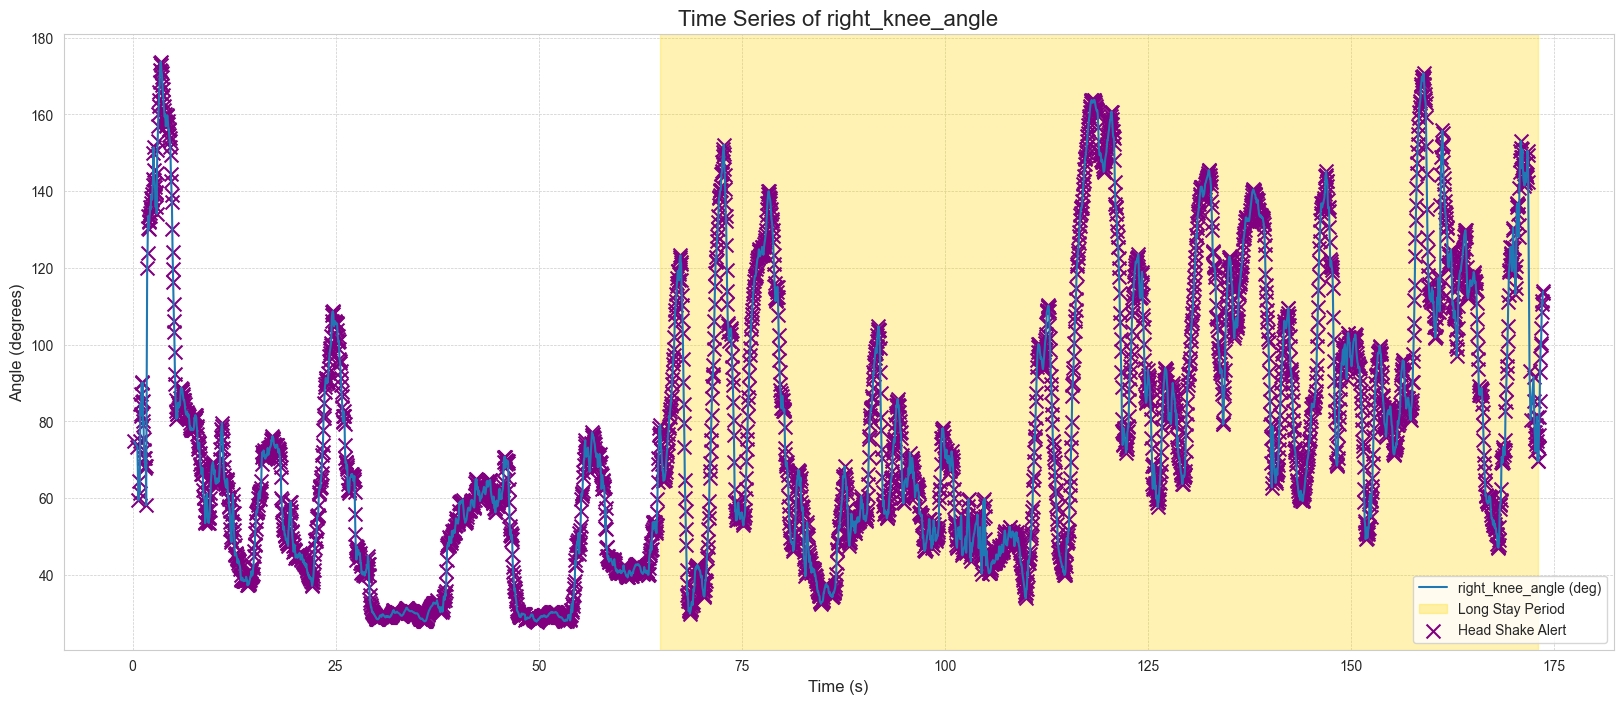

In [3]:
if 'df' in locals():
    # 分析したい角度のカラム名
    angle_to_plot = 'right_knee_angle'
    
    plt.figure(figsize=(20, 8))
    
    # 角度の時系列プロット
    sns.lineplot(x='timestamp', y=angle_to_plot, data=df, label=f'{angle_to_plot} (deg)')
    
    # 長期滞在検知のアラートがあった箇所をハイライト
    long_stay_events = df[df['is_long_stay'] == True]
    if not long_stay_events.empty:
        plt.axvspan(long_stay_events['timestamp'].min(), long_stay_events['timestamp'].max(), color='gold', alpha=0.3, label='Long Stay Period')

    # 首振り検知のアラートがあった箇所をマーク
    shake_events = df[df['head_shake_alerts'] != '']
    if not shake_events.empty:
        plt.scatter(shake_events['timestamp'], shake_events[angle_to_plot], color='purple', marker='x', s=100, label='Head Shake Alert')

    plt.title(f'Time Series of {angle_to_plot}', fontsize=16)
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Angle (degrees)', fontsize=12)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()
else:
    print("データフレームが読み込まれていないため、プロットをスキップします。")


## 3. 頭部の動きの軌跡

鼻（NOSE）のランドマークのX, Y座標をプロットし、頭部がどのように動いたかの軌跡を可視化します。これにより、特定のパターン（例：左右を見回す動き）を捉えることができます。


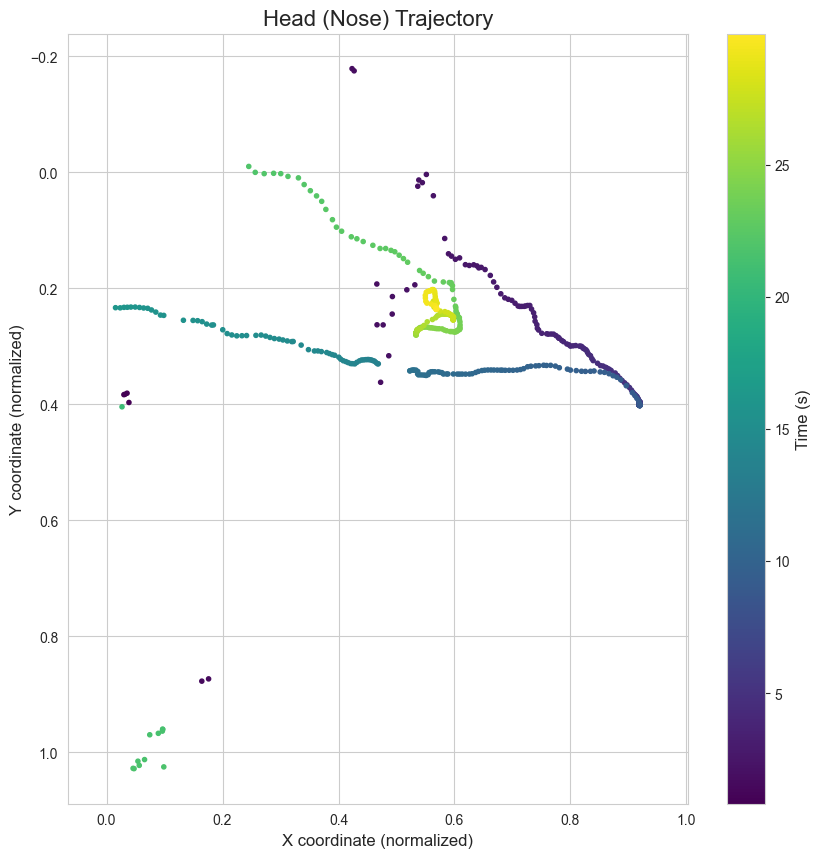

In [19]:
if 'df' in locals():
    # 鼻のx, y座標を取得 (0 < visibility < 1 のデータのみ)
    # visibilityが0のデータはノイズの可能性があるため除外
    nose_df = df[df['NOSE_visibility'] > 0.1].copy()

    # タイムスタンプを色にマッピングして、時間の経過を表現
    points = np.array([nose_df['NOSE_x'], nose_df['NOSE_y']]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    plt.figure(figsize=(10, 10))
    
    # 軌跡をプロット
    plt.scatter(nose_df['NOSE_x'], nose_df['NOSE_y'], c=nose_df['timestamp'], cmap='viridis', marker='.', label='Nose Position')
    
    # 画像の座標系に合わせてY軸を反転
    plt.gca().invert_yaxis()
    
    plt.title('Head (Nose) Trajectory', fontsize=16)
    plt.xlabel('X coordinate (normalized)', fontsize=12)
    plt.ylabel('Y coordinate (normalized)', fontsize=12)
    cbar = plt.colorbar()
    cbar.set_label('Time (s)', fontsize=12)
    plt.axis('equal')
    plt.grid(True)
    plt.show()
else:
    print("データフレームが読み込まれていないため、プロットをスキップします。")


## 4. ランドマークの信頼度(visibility)の分布

主要なランドマークの信頼度（`visibility`）の分布を箱ひげ図で可視化します。

これにより、どの身体部位がビデオ全体を通じて安定して検出されたか、あるいは隠れてしまっていた（オクルージョン）かを評価することができます。

- 箱が小さいほど、そのランドマークの信頼度が安定していたことを示します。
- 箱が低い位置にある、またはひげが下方に長く伸びている場合、そのランドマークが見えなくなる瞬間が多かったことを示唆します。


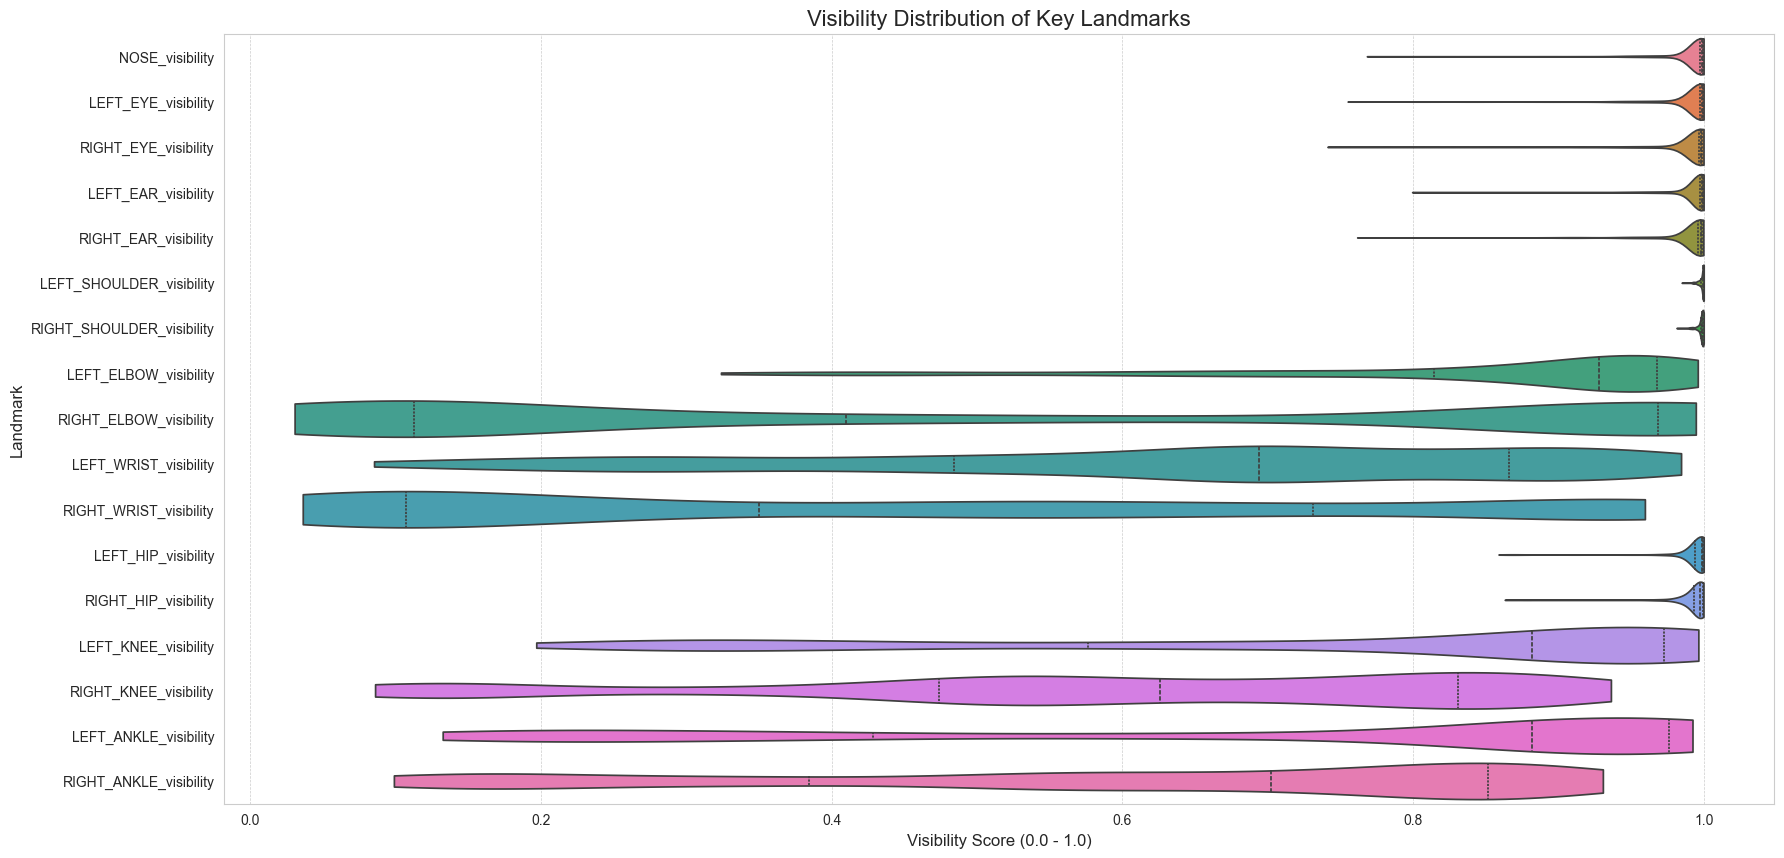

In [20]:
if 'df' in locals():
    # 分析対象とする主要なランドマーク
    key_landmarks = [
        'NOSE', 'LEFT_EYE', 'RIGHT_EYE', 'LEFT_EAR', 'RIGHT_EAR',
        'LEFT_SHOULDER', 'RIGHT_SHOULDER', 'LEFT_ELBOW', 'RIGHT_ELBOW',
        'LEFT_WRIST', 'RIGHT_WRIST', 'LEFT_HIP', 'RIGHT_HIP',
        'LEFT_KNEE', 'RIGHT_KNEE', 'LEFT_ANKLE', 'RIGHT_ANKLE'
    ]
    
    # visibilityのカラムだけを抽出
    visibility_cols = [f'{lm}_visibility' for lm in key_landmarks if f'{lm}_visibility' in df.columns]
    visibility_df = df[visibility_cols]
    
    plt.figure(figsize=(20, 10))
    
    # バイオリンプロットで分布をプロット
    sns.violinplot(data=visibility_df, orient='h', inner='quartile', cut=0)
    
    plt.title('Visibility Distribution of Key Landmarks', fontsize=16)
    plt.xlabel('Visibility Score (0.0 - 1.0)', fontsize=12)
    plt.ylabel('Landmark', fontsize=12)
    plt.grid(True, axis='x', linestyle='--', linewidth=0.5)
    plt.show()
else:
    print("データフレームが読み込まれていないため、プロットをスキップします。")


## 5. 動作状態の分布

動画全体を通して、主要な関節が各動作状態（静止、屈曲、伸展など）にどれくらいの割合で分類されたかを確認します。

これにより、被写体の全体的な活動レベルや、特定の姿勢（例：膝を曲げた状態が長い）の頻度を把握することができます。


/var/folders/xw/k40c15cs6tq2523pwfk3bmdc0000gn/T/ipykernel_52535/1560983956.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, ax=axes[plot_count], palette='viridis', order=df[col].value_counts().index)
/var/folders/xw/k40c15cs6tq2523pwfk3bmdc0000gn/T/ipykernel_52535/1560983956.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, ax=axes[plot_count], palette='viridis', order=df[col].value_counts().index)
/var/folders/xw/k40c15cs6tq2523pwfk3bmdc0000gn/T/ipykernel_52535/1560983956.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the 

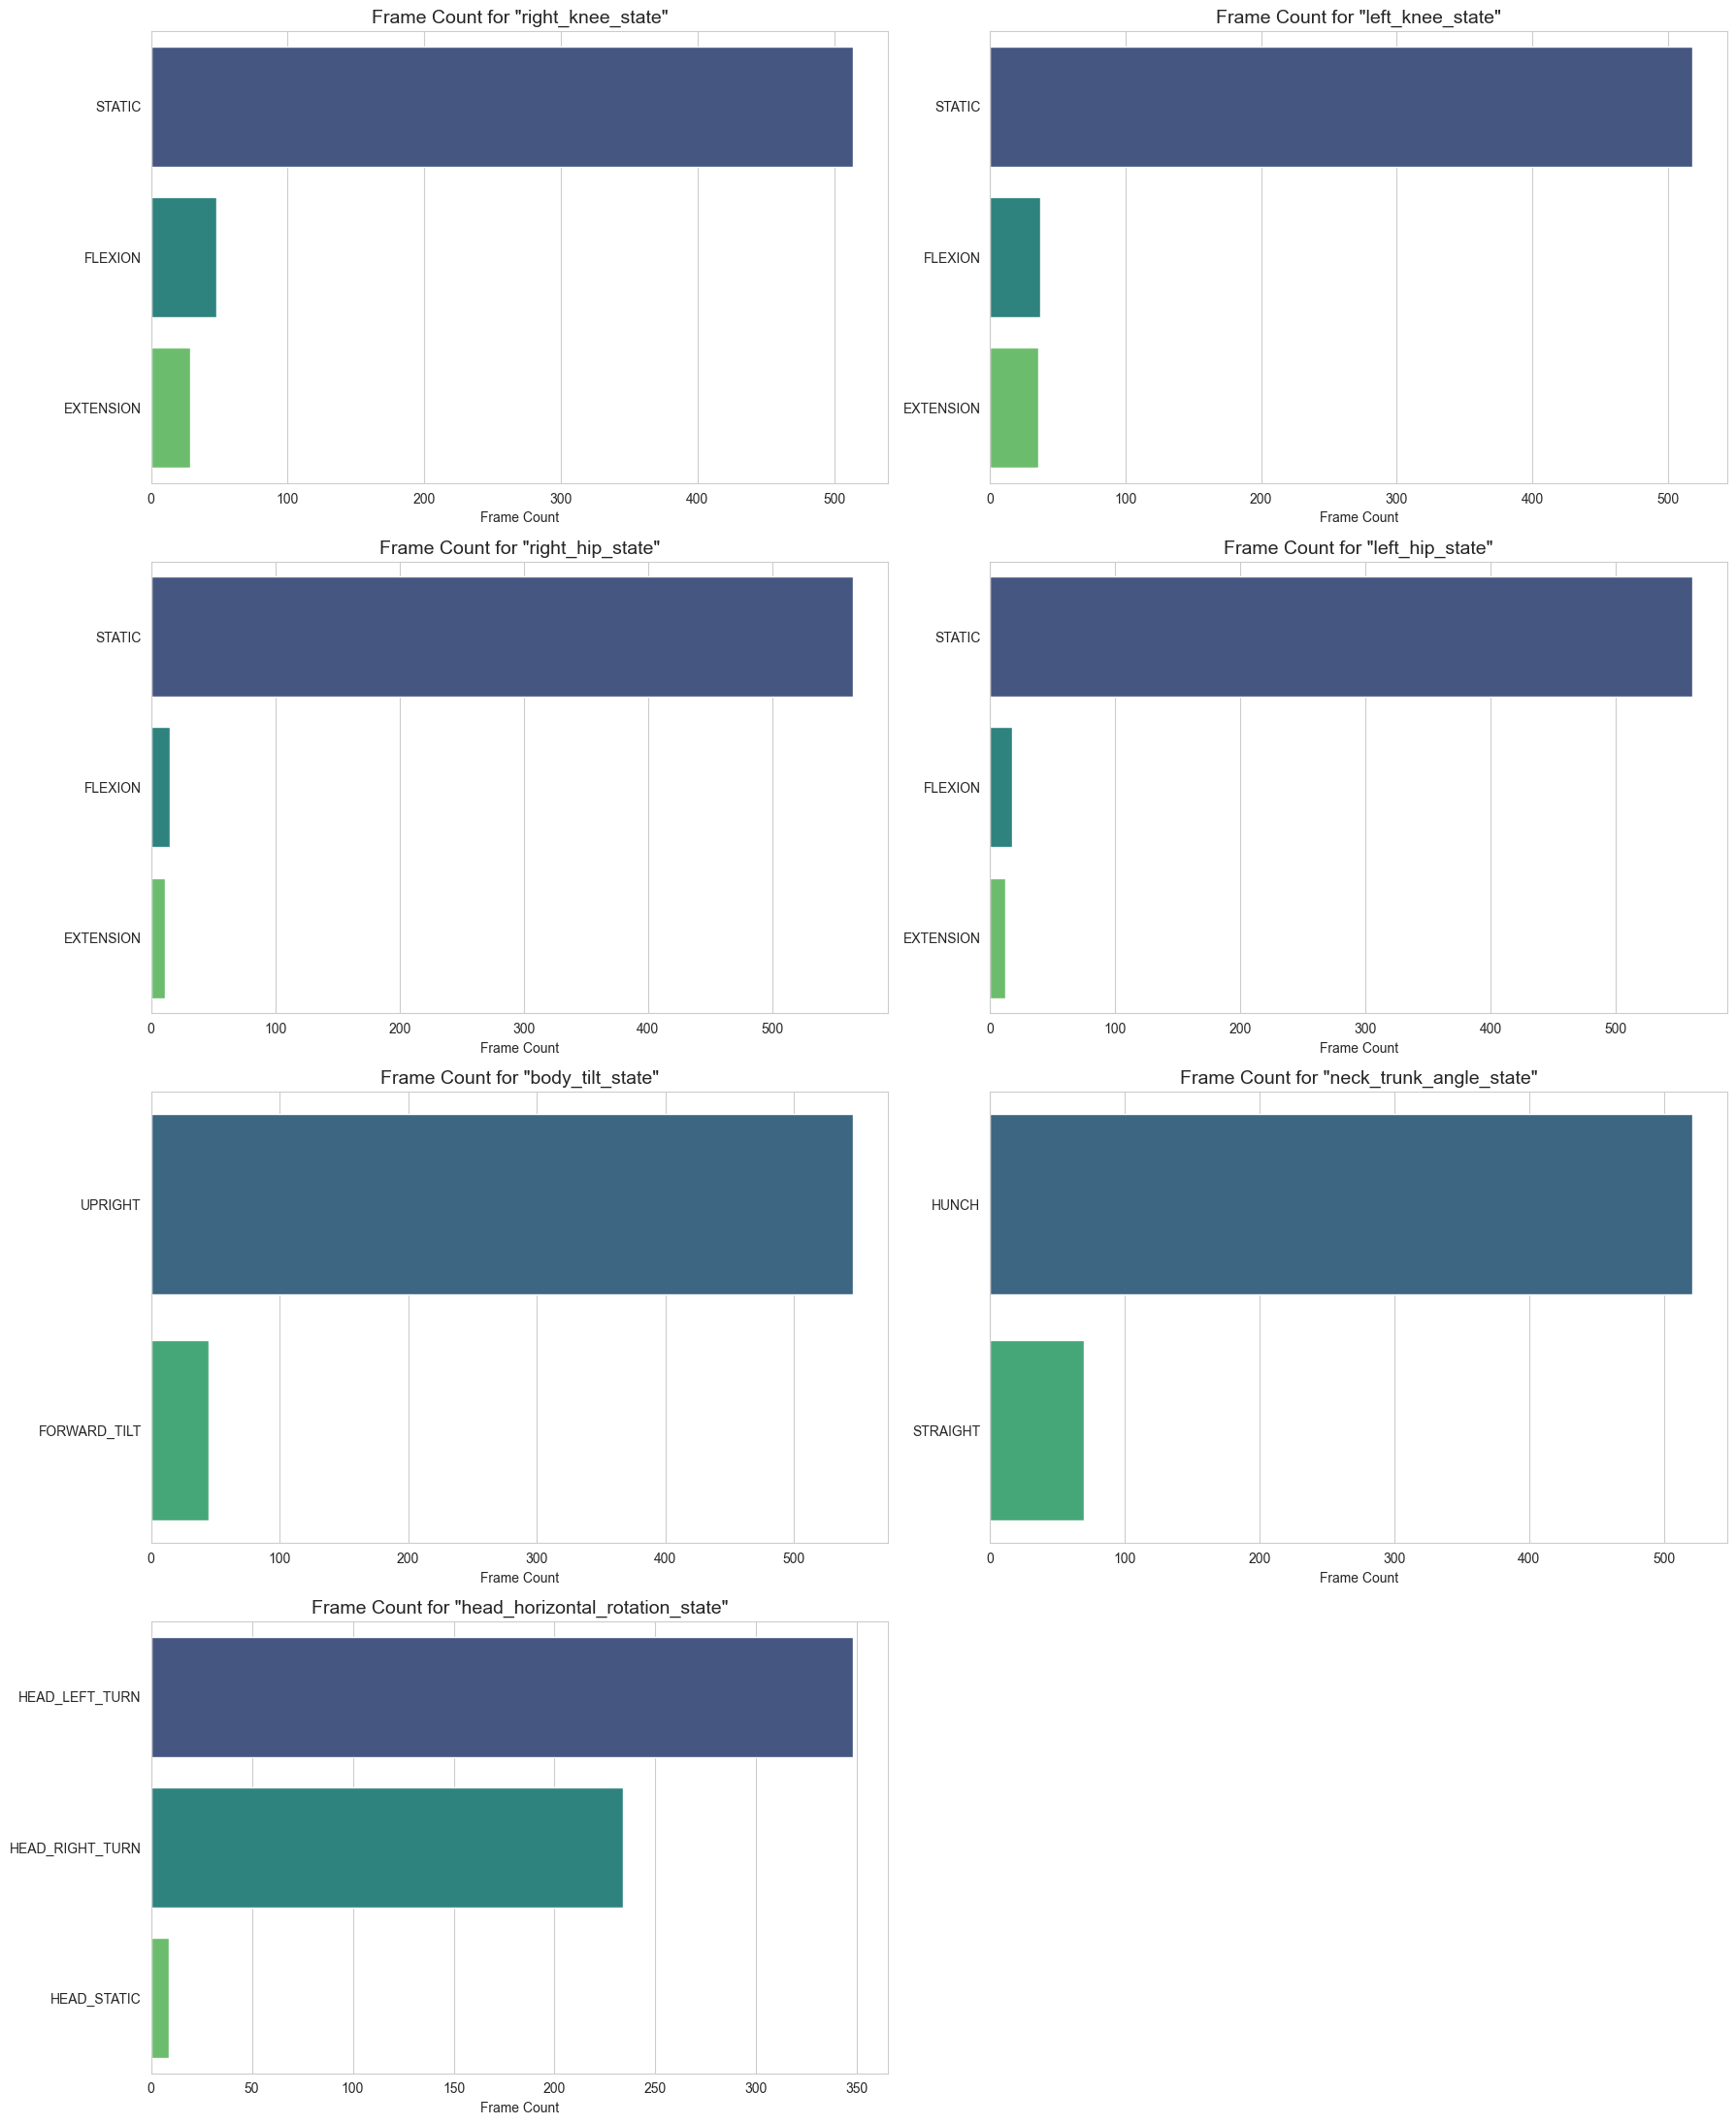

In [21]:
if 'df' in locals():
    # 分析したい状態のカラム
    state_cols = [
        'right_knee_state', 'left_knee_state',
        'right_hip_state', 'left_hip_state',
        'body_tilt_state', 'neck_trunk_angle_state',
        'head_horizontal_rotation_state'
    ]
    
    # 2x4のサブプロットを作成
    fig, axes = plt.subplots(4, 2, figsize=(18, 22))
    axes = axes.flatten() # 2次元配列を1次元に変換して扱いやすくする

    # カラムが存在するかチェックしながらプロット
    plot_count = 0
    for i, col in enumerate(state_cols):
        if col in df.columns:
            sns.countplot(y=col, data=df, ax=axes[plot_count], palette='viridis', order=df[col].value_counts().index)
            axes[plot_count].set_title(f'"{col}" のフレーム数', fontsize=14)
            axes[plot_count].set_xlabel('フレーム数', fontsize=10)
            axes[plot_count].set_ylabel('')
            plot_count += 1

    # 不要なサブプロットを非表示にする
    for i in range(plot_count, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

else:
    print("データフレームが読み込まれていないため、プロットをスキップします。")


## 6. 信頼度(Visibility)による角度の精度分析

ランドマークの検出信頼度（`visibility`）が、計算される関節角度の精度にどのような影響を与えるかを、**複数の代表的な角度（脚、腕、体幹）**について分析します。

ここでは、角度の計算に使用するランドマーク全ての信頼度が **80% (0.8) 以上** の場合を「高信頼度データ」、それ以外を「低信頼度データ」と分類します。

両グループで角度の分布を比較することで、信頼度の低いランドマークが計算結果に外れ値やノイズをどの程度生じさせるかを評価できます。


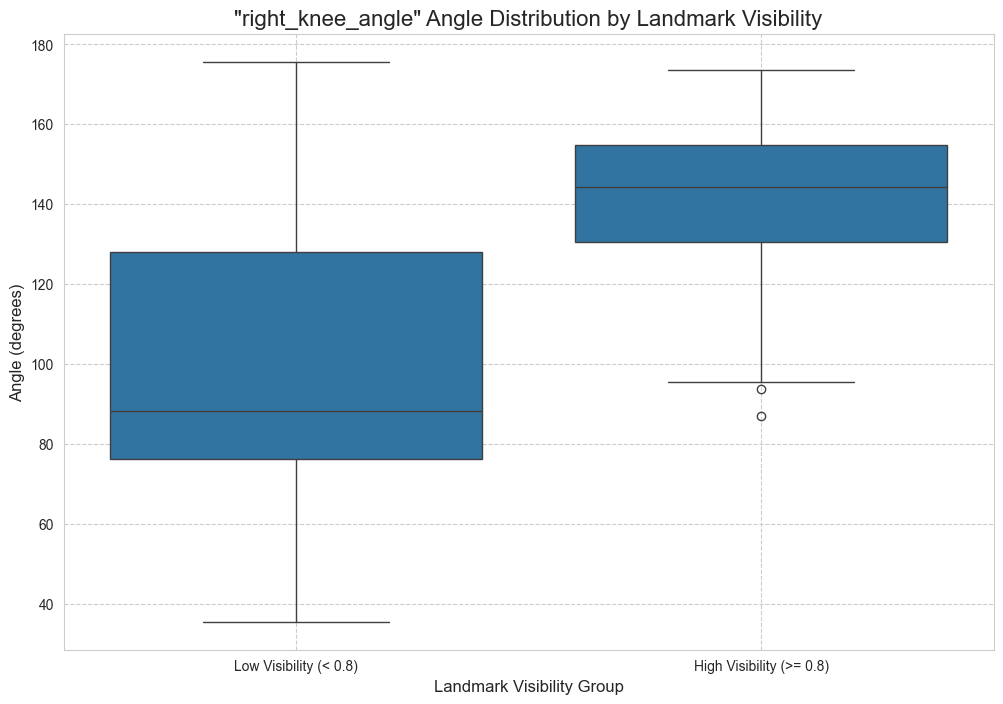

--- [ right_knee_angle ] Visibility Groupごとの統計量 ---


,count,mean,std,min,25%,50%,75%,max
confidence_group,,,,,,,,
High Visibility (>= 0.8),166.0,142.548624,16.506380,86.933340,130.507110,144.206424,154.742545,173.589849
Low Visibility (< 0.8),425.0,100.370801,36.839539,35.496331,76.181337,88.130753,128.116911,175.643130


\n================================================================================\n


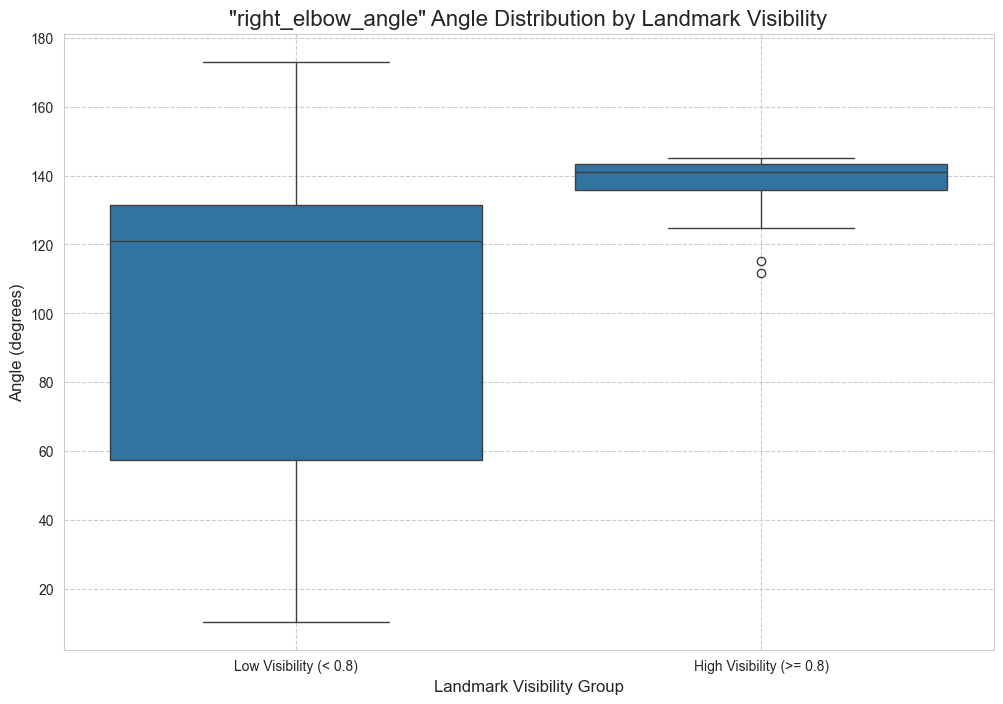

--- [ right_elbow_angle ] Visibility Groupごとの統計量 ---


,count,mean,std,min,25%,50%,75%,max
confidence_group,,,,,,,,
High Visibility (>= 0.8),128.0,138.766654,6.229242,111.578551,135.795092,141.093453,143.278584,145.026439
Low Visibility (< 0.8),463.0,100.801873,45.301739,10.405815,57.457377,120.926493,131.558847,173.106839


\n================================================================================\n


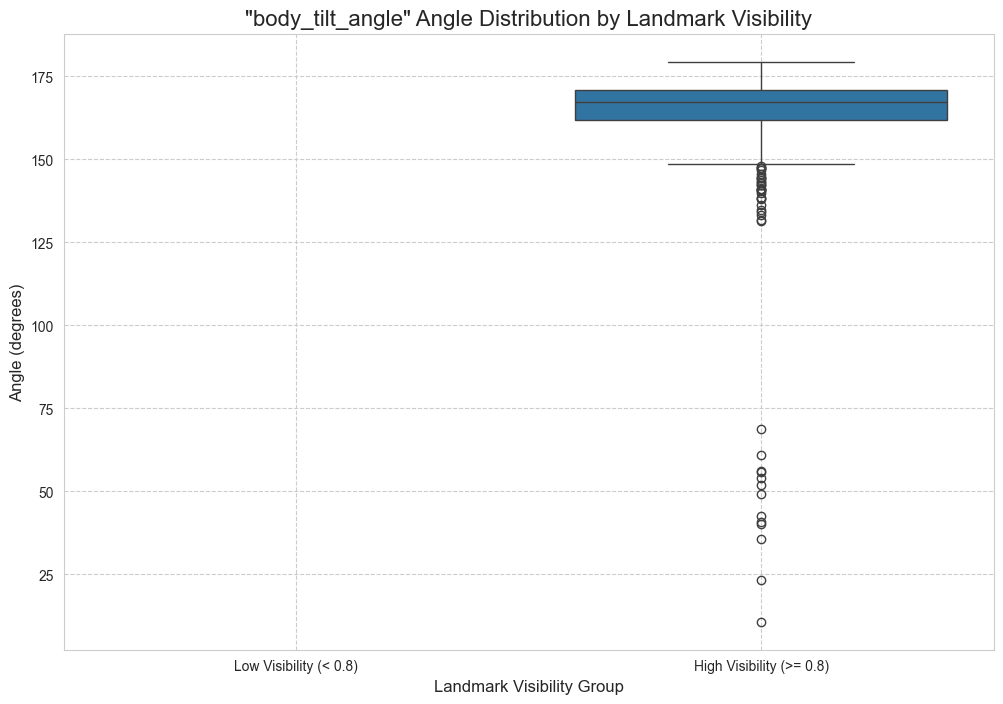

--- [ body_tilt_angle ] Visibility Groupごとの統計量 ---


,count,mean,std,min,25%,50%,75%,max
confidence_group,,,,,,,,
High Visibility (>= 0.8),591.0,163.198128,19.451512,10.799905,161.838457,167.171539,170.831994,179.464164


\n================================================================================\n


In [22]:
if 'df' in locals():
    # --- 分析する角度のリストを定義 ---
    analyses_to_run = [
        {
            'angle_col': 'right_knee_angle',
            'landmarks': ['RIGHT_HIP', 'RIGHT_KNEE', 'RIGHT_ANKLE']
        },
        {
            'angle_col': 'right_elbow_angle',
            'landmarks': ['RIGHT_SHOULDER', 'RIGHT_ELBOW', 'RIGHT_WRIST']
        },
        {
            'angle_col': 'body_tilt_angle',
            'landmarks': ['LEFT_SHOULDER', 'RIGHT_SHOULDER', 'LEFT_HIP', 'RIGHT_HIP'] # 体幹は4点の信頼性に基づく
        }
    ]
    visibility_threshold = 0.8
    # --- ここまで ---

    # 定義された各分析をループで実行
    for analysis in analyses_to_run:
        angle_col = analysis['angle_col']
        landmark_names = analysis['landmarks']
        
        # 必要なvisibilityカラム名を作成
        visibility_cols = [f'{lm}_visibility' for lm in landmark_names]

        # 関連するランドマークのvisibilityから、そのフレームでの角度の信頼度（最低値）を計算
        df['angle_confidence'] = df[visibility_cols].min(axis=1)

        # 信頼度に基づいてグループ分け
        df['confidence_group'] = np.where(df['angle_confidence'] >= visibility_threshold, 
                                          f'High Visibility (>= {visibility_threshold})', 
                                          f'Low Visibility (< {visibility_threshold})')

        # --- 可視化 ---
        plt.figure(figsize=(12, 8))
        sns.boxplot(x='confidence_group', y=angle_col, data=df, order=[f'Low Visibility (< {visibility_threshold})', f'High Visibility (>= {visibility_threshold})'])
        
        plt.title(f'"{angle_col}" Angle Distribution by Landmark Visibility', fontsize=16)
        plt.xlabel('Landmark Visibility Group', fontsize=12)
        plt.ylabel('Angle (degrees)', fontsize=12)
        plt.grid(True, linestyle='--')
        plt.show()

        # --- 統計量の比較 ---
        print(f"--- [ {angle_col} ] Visibility Groupごとの統計量 ---")
        stats = df.groupby('confidence_group')[angle_col].describe()
        display(stats)
        print("\\n" + "="*80 + "\\n")


else:
    print("データフレームが読み込まれていないため、分析をスキップします。")


## 7. 詳細分析: 右膝角度 (Right Knee Angle) とその信頼性

特定の関節角度、ここでは`RIGHT_KNEE_ANGLE`に焦点を当て、その計算の信頼性を深掘りします。

**分析内容:**
1. **ランドマーク毎の信頼度**: 角度計算に使われる3つのランドマーク（`RIGHT_HIP`, `RIGHT_KNEE`, `RIGHT_ANKLE`）それぞれの`visibility`が時間と共にどう変化するかを可視化します。これにより、どの部位が隠れやすい（オクルージョンが多い）かが分かります。
2. **角度と信頼度の相関**: 実際の角度の変動と、その角度の信頼度（3つのランドマークの`visibility`の最低値）を同じグラフにプロットします。これにより、信頼度が低い瞬間に角度の計算が不安定になっていないかを確認できます。


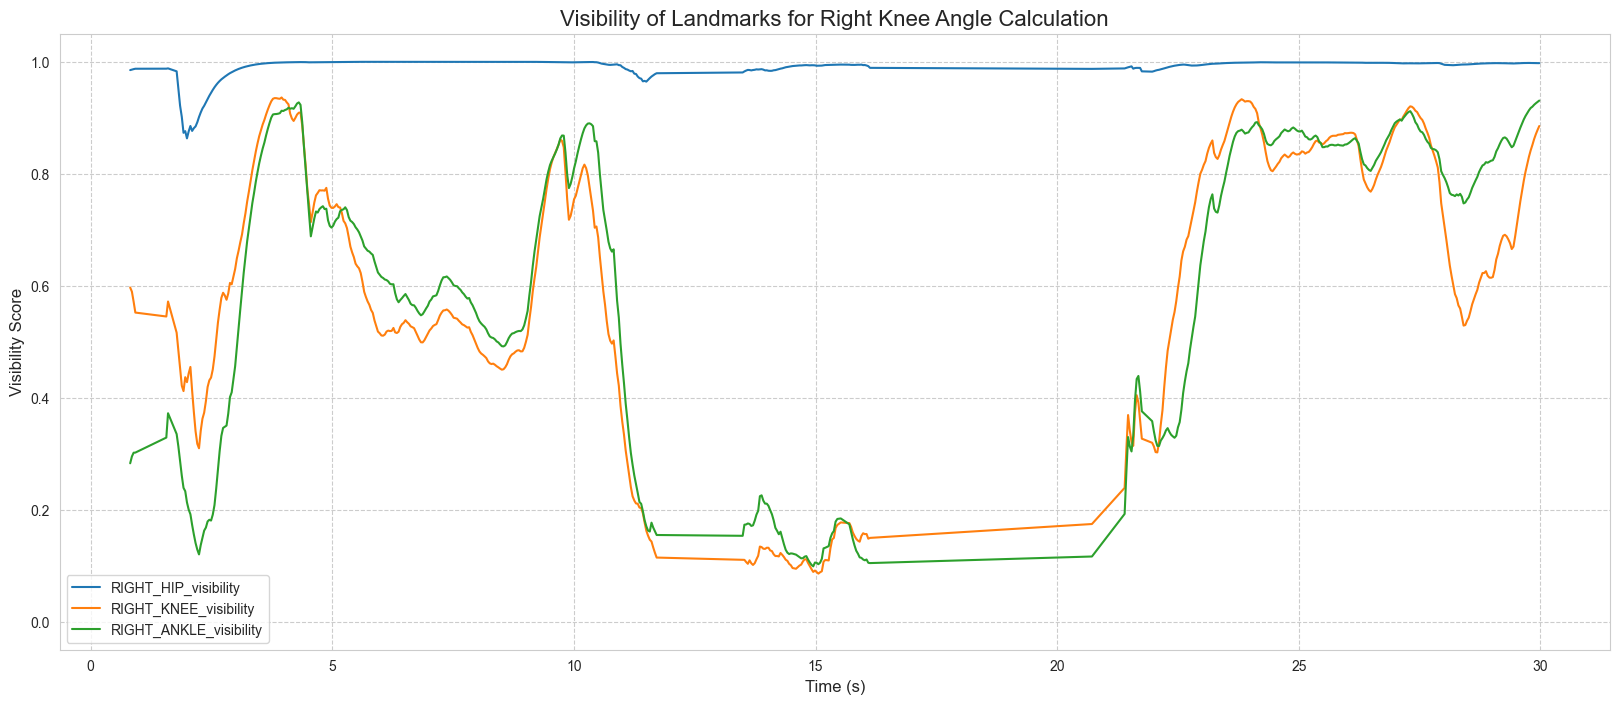

In [23]:
if 'df' in locals():
    # --- 1. ランドマーク毎の信頼度を可視化 ---
    landmarks_for_knee = ['RIGHT_HIP_visibility', 'RIGHT_KNEE_visibility', 'RIGHT_ANKLE_visibility']
    
    plt.figure(figsize=(20, 8))
    for col in landmarks_for_knee:
        sns.lineplot(x='timestamp', y=col, data=df, label=col)
        
    plt.title('Visibility of Landmarks for Right Knee Angle Calculation', fontsize=16)
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Visibility Score', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.ylim(-0.05, 1.05) # y軸の範囲を0-1に固定
    plt.show()

else:
    print("データフレームが読み込まれていないため、分析をスキップします。")


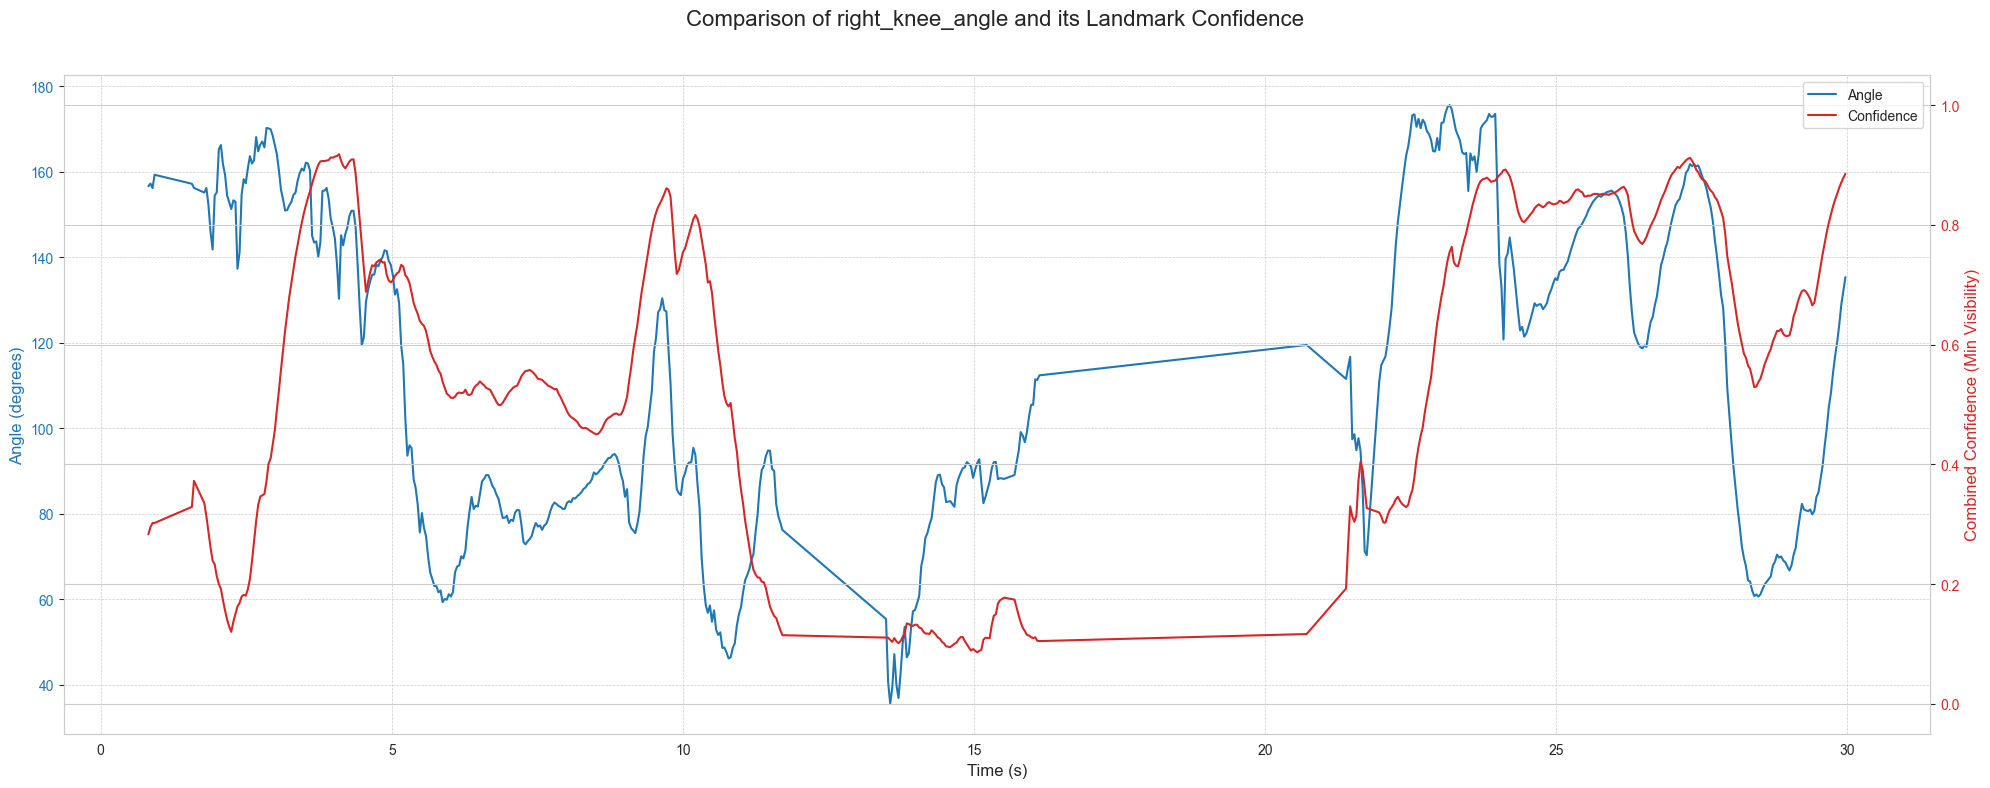

In [24]:
if 'df' in locals():
    # --- 2. 角度と信頼度の相関を可視化 ---
    angle_col = 'right_knee_angle'
    visibility_cols = ['RIGHT_HIP_visibility', 'RIGHT_KNEE_visibility', 'RIGHT_ANKLE_visibility']
    
    # 角度の信頼度を計算 (3つのランドマークの最低値)
    df['angle_confidence'] = df[visibility_cols].min(axis=1)

    fig, ax1 = plt.subplots(figsize=(20, 8))

    # 左側のY軸: 角度をプロット (青色)
    color = 'tab:blue'
    ax1.set_xlabel('Time (s)', fontsize=12)
    ax1.set_ylabel('Angle (degrees)', color=color, fontsize=12)
    sns.lineplot(x='timestamp', y=angle_col, data=df, ax=ax1, color=color, label='Angle')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

    # 右側のY軸: 信頼度をプロット (赤色)
    ax2 = ax1.twinx()  # 2つ目のY軸を作成
    color = 'tab:red'
    ax2.set_ylabel('Combined Confidence (Min Visibility)', color=color, fontsize=12)
    sns.lineplot(x='timestamp', y='angle_confidence', data=df, ax=ax2, color=color, label='Confidence')
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(-0.05, 1.05) # y軸の範囲を0-1に固定

    fig.suptitle(f'Comparison of {angle_col} and its Landmark Confidence', fontsize=16)
    
    # 凡例をまとめる
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper right')
    ax1.get_legend().remove()

    fig.tight_layout(rect=[0, 0, 1, 0.96]) # suptitleと重ならないように調整
    plt.show()

else:
    print("データフレームが読み込まれていないため、分析をスキップします。")


## 8. 全主要ランドマークの信頼度(Visibility)時系列比較

これまで分析で使用してきた全ての主要ランドマークについて、信頼度（`visibility`）の時系列変化を一つのグラフにまとめてプロットします。

これにより、どのランドマークが動画全体を通して安定して検出されていたか、またどのランドマークが頻繁に隠れて信頼度が低下していたかを一覧で比較・評価することができます。


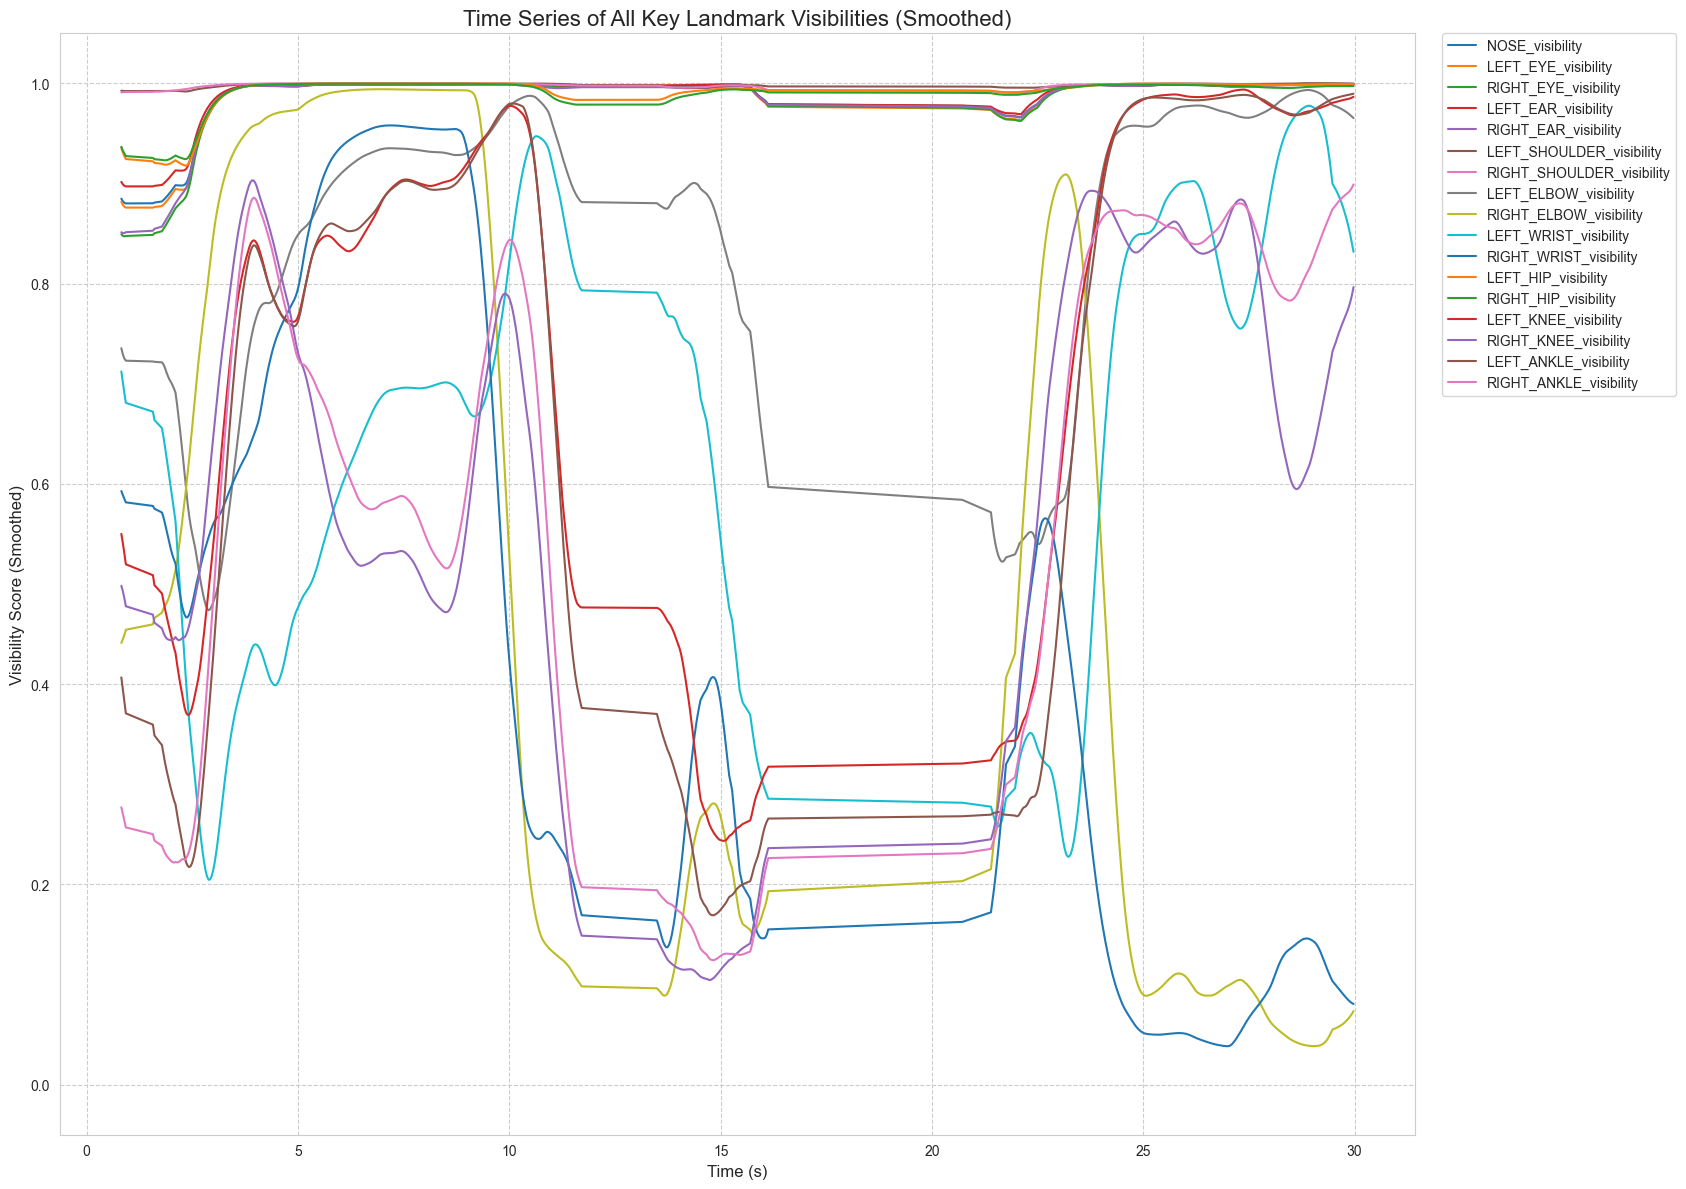

In [25]:
if 'df' in locals():
    # 分析対象とする主要なランドマーク
    key_landmarks = [
        'NOSE', 'LEFT_EYE', 'RIGHT_EYE', 'LEFT_EAR', 'RIGHT_EAR',
        'LEFT_SHOULDER', 'RIGHT_SHOULDER', 'LEFT_ELBOW', 'RIGHT_ELBOW',
        'LEFT_WRIST', 'RIGHT_WRIST', 'LEFT_HIP', 'RIGHT_HIP',
        'LEFT_KNEE', 'RIGHT_KNEE', 'LEFT_ANKLE', 'RIGHT_ANKLE'
    ]
    
    visibility_cols = [f'{lm}_visibility' for lm in key_landmarks if f'{lm}_visibility' in df.columns]

    plt.figure(figsize=(20, 12))
    
    for col in visibility_cols:
        # 全てのデータをプロットすると重なりすぎるため、移動平均を計算して滑らかにする
        # windowサイズはフレームレートに応じて調整 (例: 30fpsで1秒間の平均)
        rolling_mean = df[col].rolling(window=30, center=True, min_periods=1).mean()
        sns.lineplot(x=df['timestamp'], y=rolling_mean, label=col)

    plt.title('Time Series of All Key Landmark Visibilities (Smoothed)', fontsize=16)
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Visibility Score (Smoothed)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.grid(True, linestyle='--')
    plt.ylim(-0.05, 1.05)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # 凡例が収まるように調整
    plt.show()

else:
    print("データフレームが読み込まれていないため、分析をスキップします。")


## 9. ランドマーク信頼度の統計的ランキング

各ランドマークの信頼度（`visibility`）について、平均値、中央値、標準偏差、分散などの基本的な統計量を計算します。

そして、**平均信頼度が高い順**に並べ替えることで、どのランドマークが動画全体を通して最も安定して検出されていたかをランキング形式で評価します。

- **mean (平均値)**: 高いほど、全体的に信頼度が高かったことを示す。
- **std (標準偏差) / var (分散)**: 低いほど、信頼度のばらつきが少なく、安定していたことを示す。
- **50% (中央値)**: データの中央の値。外れ値の影響を受けにくいため、平均値と合わせて見ることで、より実態に近い信頼性を評価できる。


In [15]:
if 'df' in locals():
    # --- 表示オプションを設定 ---
    # DataFrameのすべての行と列を表示するように設定
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)

    # dfの全てのカラムから '_visibility' で終わるものを抽出
    visibility_cols = [col for col in df.columns if col.endswith('_visibility')]
    visibility_df = df[visibility_cols]

    # 基本統計量を計算
    stats_df = visibility_df.describe().transpose()
    
    # 分散を追加
    stats_df['variance'] = visibility_df.var()
    
    # カラムの順番を整理
    stats_df = stats_df[['mean', '50%', 'std', 'variance', 'min', '25%', '75%', 'max', 'count']]
    stats_df = stats_df.rename(columns={'50%': 'median'})

    # 平均信頼度(mean)で降順に並べ替え
    ranked_stats = stats_df.sort_values(by='mean', ascending=False)
    
    print("--- ランドマーク信頼度の統計ランキング (平均値が高い順) ---")
    display(ranked_stats)

    # 表示オプションを元に戻す（任意）
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_columns')

else:
    print("データフレームが読み込まれていないため、分析をスキップします。")


--- ランドマーク信頼度の統計ランキング (平均値が高い順) ---


,mean,median,std,variance,min,25%,75%,max,count
LEFT_SHOULDER_visibility,0.999775,0.999989,0.001453,2.111792e-06,0.971144,0.999927,0.999998,1.000000,4135.0
LEFT_EYE_OUTER_visibility,0.999080,0.999685,0.004082,1.666298e-05,0.931887,0.999442,0.999836,0.999993,4135.0
RIGHT_SHOULDER_visibility,0.999051,0.999274,0.000806,6.489548e-07,0.989558,0.998870,0.999509,0.999941,4135.0
LEFT_EAR_visibility,0.999041,0.999718,0.004699,2.208480e-05,0.923203,0.999478,0.999876,0.999993,4135.0
LEFT_EYE_visibility,0.998895,0.999638,0.005428,2.946233e-05,0.901908,0.999401,0.999808,0.999994,4135.0
LEFT_EYE_INNER_visibility,0.998875,0.999590,0.004859,2.361371e-05,0.910907,0.999274,0.999753,0.999994,4135.0
MOUTH_LEFT_visibility,0.998839,0.999665,0.006323,3.997996e-05,0.889956,0.999343,0.999818,0.999993,4135.0
NOSE_visibility,0.998784,0.999523,0.005279,2.786957e-05,0.906914,0.999202,0.999757,0.999995,4135.0
RIGHT_EYE_INNER_visibility,0.998699,0.999308,0.003654,1.335081e-05,0.938208,0.998776,0.999579,0.999994,4135.0
RIGHT_EYE_OUTER_visibility,0.998613,0.999182,0.003199,1.023619e-05,0.946358,0.998578,0.999523,0.999991,4135.0


## 10. 特定のランドマークグループの信頼度分析

特定の動作に関連するランドマーク群に絞って、信頼性の統計量を分析します。
ここでは、右脚と左脚を構成するランドマークのグループをそれぞれ見ていきます。


In [27]:
if 'df' in locals():
    # --- 右脚のランドマークに絞って分析 ---
    right_leg_visibility = ['RIGHT_HIP_visibility', 'RIGHT_KNEE_visibility', 'RIGHT_ANKLE_visibility']
    
    # visibilityのカラムだけを抽出
    visibility_df_right = df[right_leg_visibility]

    # 基本統計量を計算
    stats_df_right = visibility_df_right.describe().transpose()
    
    # 分散を追加
    stats_df_right['variance'] = visibility_df_right.var()
    
    # カラムの順番を整理
    stats_df_right = stats_df_right[['mean', '50%', 'std', 'variance', 'min', '25%', '75%', 'max', 'count']]
    stats_df_right = stats_df_right.rename(columns={'50%': 'median'})

    # 平均信頼度(mean)で降順に並べ替え
    ranked_stats_right = stats_df_right.sort_values(by='mean', ascending=False)
    
    print("--- 右脚ランドマークの信頼度統計 ---")
    display(ranked_stats_right)

else:
    print("データフレームが読み込まれていないため、分析をスキップします。")


--- 右脚ランドマークの信頼度統計 ---


,mean,median,std,variance,min,25%,75%,max,count
RIGHT_HIP_visibility,0.991987,0.997708,0.018579,0.000345,0.863123,0.993652,0.999223,0.999821,591.0
RIGHT_ANKLE_visibility,0.611213,0.702328,0.265467,0.070473,0.098858,0.384101,0.851518,0.930616,591.0
RIGHT_KNEE_visibility,0.602693,0.625896,0.251460,0.063232,0.085920,0.473924,0.830794,0.936149,591.0


In [17]:
if 'df' in locals():
    # --- 左脚のランドマークに絞って分析 ---
    left_leg_visibility = ['LEFT_HIP_visibility', 'LEFT_KNEE_visibility', 'LEFT_ANKLE_visibility']
    
    # visibilityのカラムだけを抽出
    visibility_df_left = df[left_leg_visibility]

    # 基本統計量を計算
    stats_df_left = visibility_df_left.describe().transpose()
    
    # 分散を追加
    stats_df_left['variance'] = visibility_df_left.var()
    
    # カラムの順番を整理
    stats_df_left = stats_df_left[['mean', '50%', 'std', 'variance', 'min', '25%', '75%', 'max', 'count']]
    stats_df_left = stats_df_left.rename(columns={'50%': 'median'})

    # 平均信頼度(mean)で降順に並べ替え
    ranked_stats_left = stats_df_left.sort_values(by='mean', ascending=False)
    
    print("--- 左脚ランドマークの信頼度統計 ---")
    display(ranked_stats_left)

else:
    print("データフレームが読み込まれていないため、分析をスキップします。")


--- 左脚ランドマークの信頼度統計 ---


,mean,median,std,variance,min,25%,75%,max,count
LEFT_HIP_visibility,0.993005,0.999766,0.054241,0.002942,0.233599,0.999604,0.999865,0.999962,4135.0
LEFT_ANKLE_visibility,0.965010,0.989730,0.125207,0.015677,0.044420,0.982078,0.993415,0.998043,4135.0
LEFT_KNEE_visibility,0.958075,0.977203,0.104099,0.010837,0.093948,0.961118,0.988520,0.999040,4135.0


## 11. 信頼度フィルタ適用前後での膝角度統計比較

`KneeAngleMonitor`に信頼度フィルタ（閾値: 0.7）を導入したことによって、左右の膝角度の統計量がどのように変化したかを比較します。

- **フィルタ適用前 (Before)**: 角度が計算されたすべてのフレームのデータ（ただし、角度が0のデータは未検出として除外）。
- **フィルタ適用後 (After)**: 角度の計算に使われた3つのランドマークの信頼度がすべて **0.7以上** のフレームのデータのみ。

この比較により、信頼性の低いデータを除外することが、統計的な安定性（特に分散や標準偏差の減少）にどれだけ寄与したかを定量的に評価します。


In [28]:
if 'df' in locals():
    confidence_threshold = 0.7
    stats_comparison = []

    for side in ['LEFT', 'RIGHT']:
        angle_col = f'{side.lower()}_knee_angle'
        visibility_cols = [f'{side}_HIP_visibility', f'{side}_KNEE_visibility', f'{side}_ANKLE_visibility']

        # --- フィルタ適用前のデータ ---
        # 角度が0より大きい（＝正しく計算された）データのみを対象
        df_before = df[df[angle_col] > 0]
        stats_before = df_before[angle_col].describe()
        stats_before['variance'] = df_before[angle_col].var()
        stats_before.name = f"{side.capitalize()} Knee (Before Filter)"
        stats_comparison.append(stats_before)

        # --- フィルタ適用後のデータ ---
        # 角度の信頼度を計算し、閾値でフィルタリング
        df['angle_confidence'] = df[visibility_cols].min(axis=1)
        df_after = df[(df[angle_col] > 0) & (df['angle_confidence'] >= confidence_threshold)]
        stats_after = df_after[angle_col].describe()
        stats_after['variance'] = df_after[angle_col].var()
        stats_after.name = f"{side.capitalize()} Knee (After Filter)"
        stats_comparison.append(stats_after)

    # 結果を一つのDataFrameにまとめて表示
    comparison_df = pd.DataFrame(stats_comparison)
    comparison_df = comparison_df[['count', 'mean', '50%', 'std', 'variance', 'min', 'max']]
    comparison_df = comparison_df.rename(columns={'50%': 'median'})
    
    display(comparison_df)

else:
    print("データフレームが読み込まれていないため、分析をスキップします。")


,count,mean,median,std,variance,min,max
Left Knee (Before Filter),591.0,144.488143,144.704090,19.755577,390.282804,96.689597,174.65226
Left Knee (After Filter),388.0,150.506495,152.932865,18.179402,330.490675,101.462923,174.65226
Right Knee (Before Filter),591.0,112.217702,108.806532,37.569164,1411.442062,35.496331,175.64313
Right Knee (After Filter),243.0,135.522900,139.062686,24.546021,602.507148,56.800625,175.64313


## 12. 2つの動画分析結果の統計比較

異なる2つの動画の分析結果（CSVファイル）を読み込み、主要な統計量を比較します。

- **動画1**: `WIN_20250319_10_03_53_Pro_30sec_integrated_analysis_20250901_102732.csv` (国宝さん5)
- **動画2**: `走行部分切り出し車椅子おばあちゃん1_integrated_analysis_20250901_105450.csv` (車椅子)

**比較項目**:
- 膝角度（左右）の統計量
- 首振り角度（水平・垂直）の統計量

これにより、被写体や状況の違いが、検出される動作の傾向にどう影響するかを定量的に評価します。


In [29]:
# --- 2つのCSVファイルのパスを指定 ---
csv_path1 = "../output/WIN_20250319_10_03_53_Pro_30sec_integrated_analysis_20250901_102732.csv"
csv_path2 = "../output/走行部分切り出し車椅子おばあちゃん1_integrated_analysis_20250901_105450.csv"

# --- データの読み込み ---
try:
    df1 = pd.read_csv(csv_path1)
    df2 = pd.read_csv(csv_path2)
    print("2つのCSVファイルの読み込みに成功しました。")
except FileNotFoundError as e:
    print(f"エラー: ファイルが見つかりません。パスを確認してください。 -> {e.filename}")

# --- 統計量の計算と表示 ---
if 'df1' in locals() and 'df2' in locals():
    
    # --- ヘルパー関数: 統計情報DataFrameを作成 ---
    def create_stats_df(series1, series2, col_names, index_map):
        stats1 = series1.describe()
        stats2 = series2.describe()
        df = pd.DataFrame({col_names[0]: stats1, col_names[1]: stats2})
        df = df.rename(index=index_map)
        # 表示を簡潔にするため、一部の統計量に絞る
        keys_to_keep = list(index_map.values())
        return df.loc[df.index.isin(keys_to_keep)]

    # --- 膝角度の統計量比較 ---
    knee_index_map = {'mean': '平均', 'std': '標準偏差', 'min': '最小値', 'max': '最大値', '50%': '中央値'}
    
    # 角度が0より大きいデータのみを対象
    left_knee1 = df1[df1['left_knee_angle'] > 0]['left_knee_angle']
    left_knee2 = df2[df2['left_knee_angle'] > 0]['left_knee_angle']
    right_knee1 = df1[df1['right_knee_angle'] > 0]['right_knee_angle']
    right_knee2 = df2[df2['right_knee_angle'] > 0]['right_knee_angle']
    
    knee_stats_df_l = create_stats_df(left_knee1, left_knee2, ['左膝 (動画1)', '左膝 (動画2)'], knee_index_map)
    knee_stats_df_r = create_stats_df(right_knee1, right_knee2, ['右膝 (動画1)', '右膝 (動画2)'], knee_index_map)
    
    # 8列で表示するためにconcat
    knee_stats_df = pd.concat([knee_stats_df_l, knee_stats_df_r], axis=1)

    # --- 首振り角度の統計量比較 ---
    head_index_map = {'mean': '平均', 'std': '標準偏差', 'min': '最小値', 'max': '最大値', '50%': '中央値'}

    # 角度が0以外のデータのみを対象
    head_h1 = df1[df1['head_horizontal_rotation_angle'] != 0]['head_horizontal_rotation_angle']
    head_h2 = df2[df2['head_horizontal_rotation_angle'] != 0]['head_horizontal_rotation_angle']
    head_v1 = df1[df1['head_vertical_nod_angle'] != 0]['head_vertical_nod_angle']
    head_v2 = df2[df2['head_vertical_nod_angle'] != 0]['head_vertical_nod_angle']

    head_stats_df_h = create_stats_df(head_h1, head_h2, ['水平 (動画1)', '水平 (動画2)'], head_index_map)
    head_stats_df_v = create_stats_df(head_v1, head_v2, ['垂直 (動画1)', '垂直 (動画2)'], head_index_map)
    head_stats_df = pd.concat([head_stats_df_h, head_stats_df_v], axis=1)

    # --- 結果の表示 ---
    print("\\n" + "="*80)
    print("--- 膝角度の統計量比較 (単位: 度) ---")
    display(knee_stats_df.style.format("{:.2f}"))
    
    print("\\n" + "="*80)
    print("--- 首振り角度の統計量比較 (単位: 度) ---")
    display(head_stats_df.style.format("{:.2f}"))



2つのCSVファイルの読み込みに成功しました。
\n================================================================================
--- 膝角度の統計量比較 (単位: 度) ---


,左膝 (動画1),左膝 (動画2),右膝 (動画1),右膝 (動画2)
平均,144.49,94.73,112.22,96.95
標準偏差,19.76,24.29,37.57,29.11
最小値,96.69,53.04,35.50,51.83
中央値,144.70,93.50,108.81,94.27
最大値,174.65,155.55,175.64,170.61


\n================================================================================
--- 首振り角度の統計量比較 (単位: 度) ---


,水平 (動画1),水平 (動画2),垂直 (動画1),垂直 (動画2)
平均,-8.16,107.50,14.78,29.50
標準偏差,142.33,38.83,17.07,9.60
最小値,-173.44,18.45,-39.27,3.53
中央値,-53.04,101.06,18.66,29.27
最大値,170.61,259.51,71.50,60.62
